In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

from osgeo import gdal

# Optional: silence the GDAL 4.0 future-warning by explicitly enabling exceptions
gdal.UseExceptions()

def find_latest_by_mtime(paths):
    paths = list(paths)
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)

def scene_from_tile(tile: str) -> str:
    # "089_084" -> "p089r084"
    p, r = tile.split("_")
    return f"p{p}r{r}"

def parse_d_range_from_name(name: str):
    # lztmre_p089r084_d2023072820240831_... -> ("20230728","20240831")
    m = re.search(r"_d(\d{8})(\d{8})_", name)
    return (m.group(1), m.group(2)) if m else (None, None)

def open_ds(path: Path):
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise FileNotFoundError(f"Could not open: {path}")
    return ds

def band_array(ds, band_idx=1):
    return ds.GetRasterBand(band_idx).ReadAsArray()

def band_stats(arr, nodata=0):
    valid = arr[arr != nodata]
    if valid.size == 0:
        return {"valid_px": 0, "min": None, "max": None, "mean": None, "median": None}
    return {
        "valid_px": int(valid.size),
        "min": float(valid.min()),
        "max": float(valid.max()),
        "mean": float(valid.mean()),
        "median": float(np.median(valid)),
    }

def unique_counts(arr):
    vals, cnt = np.unique(arr, return_counts=True)
    return dict(zip(vals.tolist(), cnt.tolist()))


In [2]:
tile = "089_084"
scene = scene_from_tile(tile)

compat_root = Path("/home/jovyan/data/compat/files") / scene
compat_root.exists(), compat_root


(False, PosixPath('/home/jovyan/data/compat/files/p089r084'))

In [3]:
# see what data is avalible:
sorted([p.name for p in compat_root.glob("lztmre_*")])[:20]


[]

### Pick the latest DLL/DLJ products

In [4]:
dll_candidates = sorted(compat_root.glob(f"lztmre_{scene}_d*_dllmz.img"))
dlj_candidates = sorted(compat_root.glob(f"lztmre_{scene}_d*_dljmz.img"))

dll_path = find_latest_by_mtime(dll_candidates)
dlj_path = find_latest_by_mtime(dlj_candidates)

dll_path, dlj_path


(None, None)

In [5]:
# dll_candidates = sorted(compat_root.glob(f"lztmre_{scene}_d*_dllmz.img"))
# dlj_candidates = sorted(compat_root.glob(f"lztmre_{scene}_d*_dljmz.img"))

# dll_path = find_latest_by_mtime(dll_candidates)
# dlj_path = find_latest_by_mtime(dlj_candidates)

# dll_path, dlj_path


In [6]:
dll_path = compat_root / f"lztmre_{scene}_d2023072820240831_vi-fpc_dllmz.img"
dlj_path = compat_root / f"lztmre_{scene}_d2023072820240831_vi-fpc_dljmz.img"


## dataset basics + per-band stats

In [7]:
def describe_dataset(path: Path):
    ds = open_ds(path)
    print("Path:", path)
    print("Size:", ds.RasterXSize, "x", ds.RasterYSize)
    print("Bands:", ds.RasterCount)
    print("Projection (EPSG-ish):", "…32756" if "32756" in ds.GetProjection() else "(see full WKT if needed)")
    print("GeoTransform:", ds.GetGeoTransform())
    print()

    for b in range(1, ds.RasterCount + 1):
        rb = ds.GetRasterBand(b)
        nodata = rb.GetNoDataValue()
        if nodata is None:
            nodata = 0
        arr = rb.ReadAsArray()
        st = band_stats(arr, nodata=nodata)
        print(f"Band {b}: dtype={gdal.GetDataTypeName(rb.DataType)} nodata={nodata} stats={st}")
    print("-" * 80)

describe_dataset(dll_path)
describe_dataset(dlj_path)


RuntimeError: /home/jovyan/data/compat/files/p089r084/lztmre_p089r084_d2023072820240831_vi-fpc_dllmz.img: No such file or directory

In [8]:
ds_dll = open_ds(dll_path)
dll = band_array(ds_dll, 1)

counts = unique_counts(dll)
# show only first ~30 keys for readability
print("DLL unique classes:", dict(list(sorted(counts.items()))[:30]))
print("Total px:", dll.size, "Non-zero px:", int((dll != 0).sum()))


RuntimeError: /home/jovyan/data/compat/files/p089r084/lztmre_p089r084_d2023072820240831_vi-fpc_dllmz.img: No such file or directory

In [9]:
plt.figure(figsize=(10, 7))
plt.imshow(dll, interpolation="nearest")
plt.title(f"DLL classification: {dll_path.name}")
plt.colorbar(label="Class value")
plt.show()


NameError: name 'dll' is not defined

<Figure size 1000x700 with 0 Axes>

In [10]:
ds_dlj = open_ds(dlj_path)

for b in range(1, ds_dlj.RasterCount + 1):
    arr = band_array(ds_dlj, b)
    nodata = ds_dlj.GetRasterBand(b).GetNoDataValue()
    nodata = 0 if nodata is None else nodata
    
    valid = arr[arr != nodata]
    print(f"DLJ band {b}: valid={valid.size}/{arr.size} min={valid.min() if valid.size else None} max={valid.max() if valid.size else None}")

    # Map
    plt.figure(figsize=(10, 7))
    plt.imshow(arr, interpolation="nearest")
    plt.title(f"DLJ band {b}: {dlj_path.name}")
    plt.colorbar(label=f"Band {b} value")
    plt.show()

    # Histogram (mean + median lines as you like)
    plt.figure(figsize=(10, 4))
    if valid.size:
        plt.hist(valid.ravel(), bins=100)
        plt.axvline(valid.mean(), linestyle="--", linewidth=2, label=f"Mean={valid.mean():.2f}")
        plt.axvline(np.median(valid), linestyle=":", linewidth=2, label=f"Median={np.median(valid):.2f}")
        plt.title(f"DLJ band {b} histogram (non-nodata)")
        plt.legend()
    else:
        plt.title(f"DLJ band {b} histogram — no valid pixels")
    plt.show()


RuntimeError: /home/jovyan/data/compat/files/p089r084/lztmre_p089r084_d2023072820240831_vi-fpc_dljmz.img: No such file or directory

In [17]:
dc4_files = sorted(compat_root.glob(f"lztmre_{scene}_*_dc4mz.img"))
print("dc4 count:", len(dc4_files))
dc4_files[:10]


dc4 count: 145


[PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20151213_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20151229_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160130_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160215_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160302_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160318_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160419_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160505_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160521_dc4mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20160724_dc4mz.img')]

In [18]:
# pick a specific date if you like, else first one
dc4_path = dc4_files[0] if dc4_files else None
dc4_path


PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20151213_dc4mz.img')

dc4 stats: {'valid_px': 55952100, 'min': 2.0, 'max': 255.0, 'mean': 204.95005365303535, 'median': 255.0} file: lztmre_p089r084_20151213_dc4mz.img


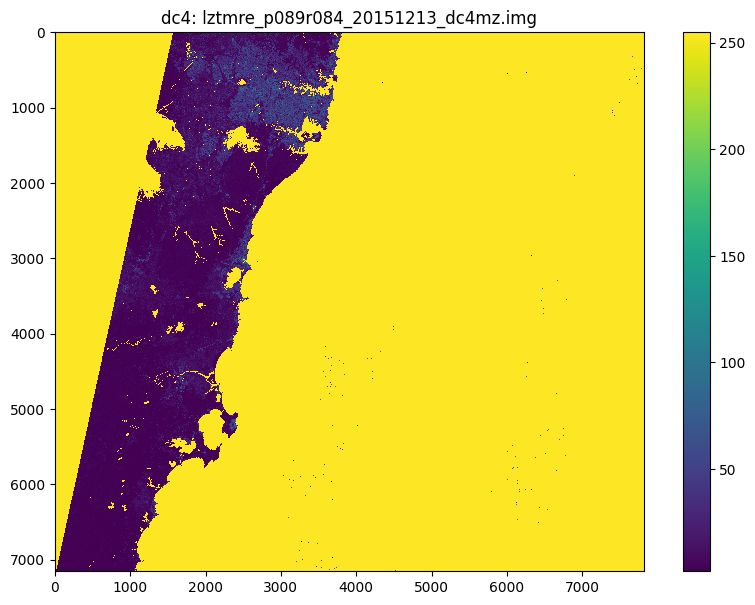

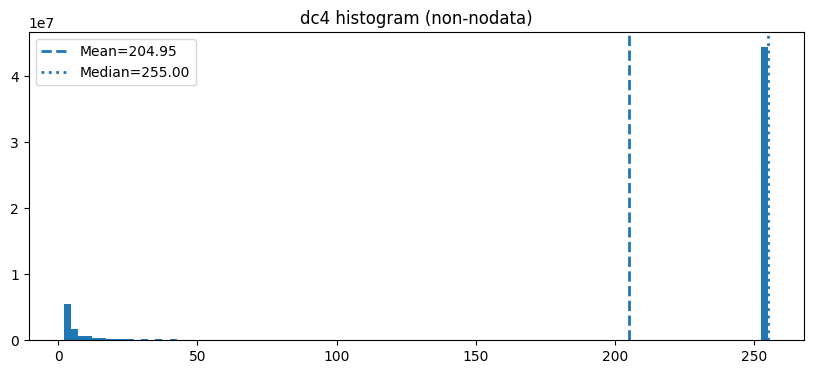

In [19]:
if dc4_path:
    ds = open_ds(dc4_path)
    arr = band_array(ds, 1)
    nodata = ds.GetRasterBand(1).GetNoDataValue()
    nodata = 0 if nodata is None else nodata
    
    st = band_stats(arr, nodata=nodata)
    print("dc4 stats:", st, "file:", dc4_path.name)

    plt.figure(figsize=(10, 7))
    plt.imshow(arr, interpolation="nearest")
    plt.title(f"dc4: {dc4_path.name}")
    plt.colorbar()
    plt.show()

    valid = arr[arr != nodata]
    plt.figure(figsize=(10, 4))
    plt.hist(valid.ravel(), bins=100)
    plt.axvline(valid.mean(), linestyle="--", linewidth=2, label=f"Mean={valid.mean():.2f}")
    plt.axvline(np.median(valid), linestyle=":", linewidth=2, label=f"Median={np.median(valid):.2f}")
    plt.title("dc4 histogram (non-nodata)")
    plt.legend()
    plt.show()


In [20]:
db8_files = sorted(compat_root.glob(f"lztmre_{scene}_*_db8mz.img"))
print("db8 count:", len(db8_files))
db8_files[:10]


db8 count: 2


[PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20230728_db8mz.img'),
 PosixPath('/home/jovyan/data/compat/files/p089r084/lztmre_p089r084_20240831_db8mz.img')]


DB8: lztmre_p089r084_20230728_db8mz.img bands: 6
  Band 1 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 7769.0, 'mean': -807.6699445597217, 'median': -999.0}
  Band 2 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 9543.0, 'mean': -778.8170510668947, 'median': -999.0}
  Band 3 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -776.6422911561854, 'median': -999.0}
  Band 4 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -481.65711240507505, 'median': -999.0}
  Band 5 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -637.5625067870553, 'median': -999.0}
  Band 6 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -729.8246015431056, 'median': -999.0}


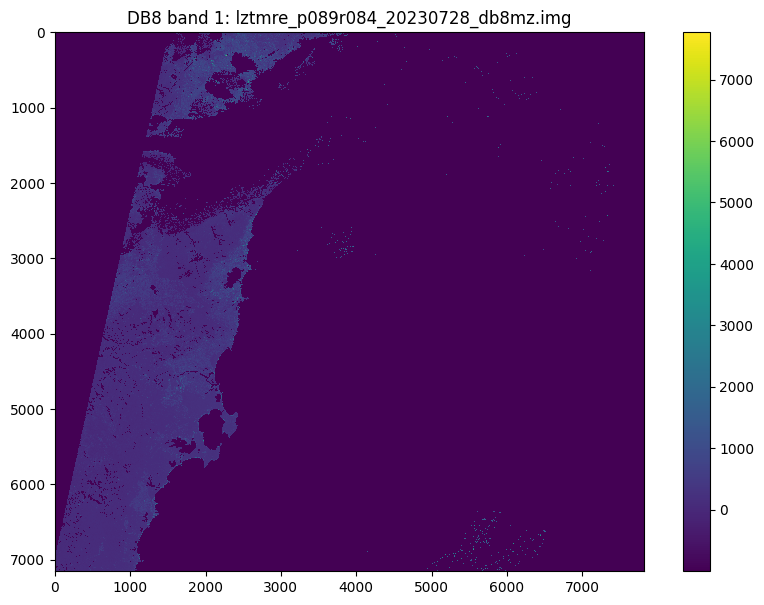


DB8: lztmre_p089r084_20240831_db8mz.img bands: 6
  Band 1 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -708.4038485061329, 'median': -999.0}
  Band 2 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -669.7313922444376, 'median': -999.0}
  Band 3 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -672.1460504610193, 'median': -999.0}
  Band 4 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -235.18133238966902, 'median': -999.0}
  Band 5 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -445.8642342825381, 'median': -999.0}
  Band 6 stats: {'valid_px': 55952100, 'min': -999.0, 'max': 10000.0, 'mean': -585.6561487057679, 'median': -999.0}


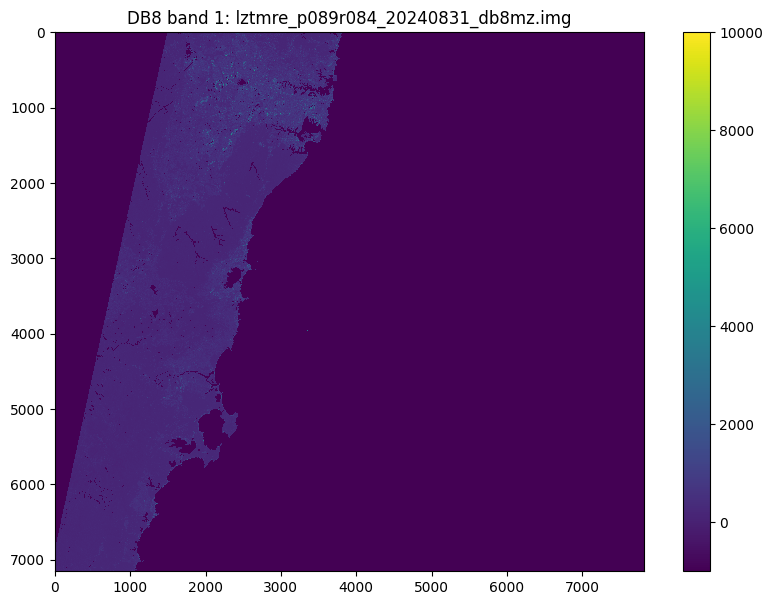

In [21]:
# If you know your start/end dates, set them; otherwise pick two
db8_start = compat_root / f"lztmre_{scene}_20230728_db8mz.img"
db8_end   = compat_root / f"lztmre_{scene}_20240831_db8mz.img"

for p in [db8_start, db8_end]:
    if p.exists():
        ds = open_ds(p)
        print("\nDB8:", p.name, "bands:", ds.RasterCount)
        for b in range(1, min(ds.RasterCount, 6) + 1):
            arr = band_array(ds, b)
            nodata = ds.GetRasterBand(b).GetNoDataValue()
            nodata = 0 if nodata is None else nodata
            st = band_stats(arr, nodata=nodata)
            print(f"  Band {b} stats:", st)

        # show band 1 map as a quick visual
        arr1 = band_array(ds, 1)
        plt.figure(figsize=(10, 7))
        plt.imshow(arr1, interpolation="nearest")
        plt.title(f"DB8 band 1: {p.name}")
        plt.colorbar()
        plt.show()
    else:
        print("Missing:", p)


In [22]:
summary = {}

# DLL
ds = open_ds(dll_path)
dll = band_array(ds, 1)
summary["dll_unique"] = unique_counts(dll)
summary["dll_nonzero"] = int((dll != 0).sum())
summary["dll_total"] = int(dll.size)

# DLJ
ds = open_ds(dlj_path)
summary["dlj"] = {}
for b in range(1, ds.RasterCount + 1):
    arr = band_array(ds, b)
    nodata = ds.GetRasterBand(b).GetNoDataValue()
    nodata = 0 if nodata is None else nodata
    summary["dlj"][f"band_{b}"] = band_stats(arr, nodata=nodata)

# dc4 count
summary["dc4_count"] = len(dc4_files)
summary


{'dll_unique': {10: 52002467,
  34: 144093,
  35: 66993,
  36: 99897,
  37: 181074,
  38: 420080,
  39: 3037496},
 'dll_nonzero': 55952100,
 'dll_total': 55952100,
 'dlj': {'band_1': {'valid_px': 12411067,
   'min': 1.0,
   'max': 255.0,
   'mean': 127.09952939582068,
   'median': 167.0},
  'band_2': {'valid_px': 21453729,
   'min': 1.0,
   'max': 248.0,
   'mean': 127.50439492360512,
   'median': 128.0},
  'band_3': {'valid_px': 55952100,
   'min': 59.0,
   'max': 200.0,
   'mean': 127.50412222240095,
   'median': 124.0},
  'band_4': {'valid_px': 8652665,
   'min': 1.0,
   'max': 200.0,
   'mean': 104.42068900159661,
   'median': 108.0}},
 'dc4_count': 145}

## Overlay “potential clearing” from DLJ on top of DLL (plus quick counts)

Overlay using DLJ band 4 with threshold >= 50
Mask pixels: 4555127 of 55952100 (8.14%)
DLL unique classes (first 20): {10: 52002467, 34: 144093, 35: 66993, 36: 99897, 37: 181074, 38: 420080, 39: 3037496}


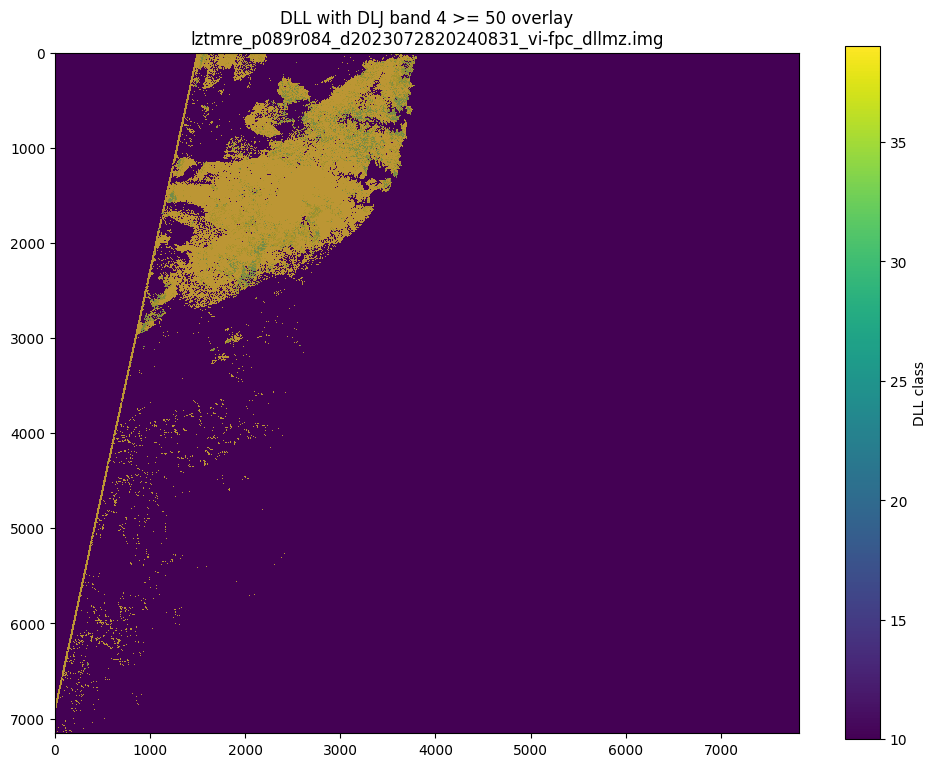

In [23]:
# --- choose which DLJ band to threshold ---
# Based on your earlier stats, band 4 looked like a "probability" (0..200-ish).
DLJ_BAND = 4

# --- choose a threshold ---
# Start with something modest; adjust after you see the overlay.
THR = 50  # try 20, 50, 100 depending on how conservative you want it

# --- load DLL + DLJ band ---
ds_dll = open_ds(dll_path)
dll = band_array(ds_dll, 1)

ds_dlj = open_ds(dlj_path)
dlj = band_array(ds_dlj, DLJ_BAND)
nodata_dlj = ds_dlj.GetRasterBand(DLJ_BAND).GetNoDataValue()
nodata_dlj = 0 if nodata_dlj is None else nodata_dlj

# --- build mask of "potential clearing" ---
mask = (dlj != nodata_dlj) & (dlj >= THR)

print(f"Overlay using DLJ band {DLJ_BAND} with threshold >= {THR}")
print("Mask pixels:", int(mask.sum()), "of", mask.size, f"({mask.mean()*100:.2f}%)")
print("DLL unique classes (first 20):", dict(list(sorted(unique_counts(dll).items()))[:20]))

# --- plot: DLL base + mask overlay ---
plt.figure(figsize=(12, 9))
plt.imshow(dll, interpolation="nearest")
plt.colorbar(label="DLL class")

# overlay mask in a contrasting colour with transparency
# (we won't set explicit colours if you prefer; but overlay needs one. Using default red.)
plt.imshow(np.where(mask, 1, np.nan), interpolation="nearest", alpha=0.35)
plt.title(f"DLL with DLJ band {DLJ_BAND} >= {THR} overlay\n{dll_path.name}")
plt.show()


In [24]:
inside = dll[mask]
outside = dll[~mask]

def counts_small(arr, max_items=30):
    c = unique_counts(arr)
    items = sorted(c.items(), key=lambda x: (-x[1], x[0]))[:max_items]
    return dict(items)

print("DLL counts INSIDE mask (top):", counts_small(inside))
print("DLL counts OUTSIDE mask (top):", counts_small(outside))


DLL counts INSIDE mask (top): {39: 3037496, 10: 605503, 38: 420080, 37: 181074, 34: 144084, 36: 99897, 35: 66993}
DLL counts OUTSIDE mask (top): {10: 51396964, 34: 9}


In [25]:
thresholds = [5, 10, 20, 50, 80, 100, 120, 150, 180]
rows = []

for thr in thresholds:
    m = (dlj != nodata_dlj) & (dlj >= thr)
    rows.append((thr, int(m.sum()), float(m.mean()*100)))

print("DLJ threshold sweep (band", DLJ_BAND, ")")
for thr, n, pct in rows:
    print(f"  >= {thr:3d}: {n:>10d} px  ({pct:5.2f}%)")


DLJ threshold sweep (band 4 )
  >=   5:    6434282 px  (11.50%)
  >=  10:    5614427 px  (10.03%)
  >=  20:    5010041 px  ( 8.95%)
  >=  50:    4555127 px  ( 8.14%)
  >=  80:    4410929 px  ( 7.88%)
  >= 100:    4348563 px  ( 7.77%)
  >= 120:    4296271 px  ( 7.68%)
  >= 150:    4226410 px  ( 7.55%)
  >= 180:    4151483 px  ( 7.42%)
